In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from IPython.display import display

from tqdm import tqdm

import pandas as pd

from scipy import stats

from scipy.ndimage import gaussian_filter

import pyunfold as pu

from scipy.io import loadmat
from scipy.interpolate import interp1d

from scipy.linalg import orth

In [7]:
from MCEq.core import MCEqRun
#import mceq_config as config
from MCEq import config
import crflux.models as pm
from MCEq.geometry.density_profiles import GeneralizedTarget

In [5]:
site = 'DomeC'
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))

df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)[0]
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

z_samp = Prop.z_samp

In [3]:
interaction_model="SIBYLL-2.3c"

In [8]:
from MCEq import config
config.debug_level = 0
config.enable_default_tracking = False
config.e_min = Prop.E_mu_bins[1]
config.e_max = Prop.E_mu_bins[-1]
config.max_density = Prop.rho_ice
config.dedx_material='ice'
medium = 'ice'

target = GeneralizedTarget(len_target=Prop.z_bins[-1]*100, env_density = Prop.rho_ice, env_name = 'ice')

mceq = MCEqRun(
    interaction_model=interaction_model,
    theta_deg = 0,
    density_model = target,
    medium=medium,
    primary_model = (pm.GaisserHonda, None),
)

In [10]:
mceq.matrix_builder.cont_loss_operator()

<bound method MatrixBuilder.cont_loss_operator of <MCEq.core.MatrixBuilder object at 0x7f952563bca0>>

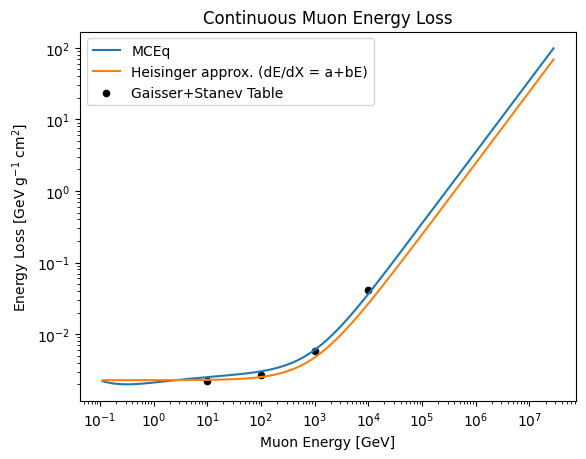

In [163]:
E_GS = np.array([10, 100, 1000, 10000]) # GeV
a_GS = np.array([2.17, 2.44, 2.68, 2.93])*1e-3 # GeV g^-1 cm^2
b_GS = np.array([1.66, 2.51, 3.17, 3.78])*1e-6 # g^-1 cm^2

plt.plot(mceq._energy_grid.c, -mceq.pman[-13].dEdX, label='MCEq')
#plt.plot(mceq._energy_grid.c, -mceq.pman[13].dEdX)
plt.plot(mceq._energy_grid.c, (Prop.a + Prop.b*mceq._energy_grid.c)/100, label='Heisinger approx. (dE/dX = a+bE)')
plt.scatter(E_GS, a_GS+b_GS*E_GS, c='k', s=20, label='Gaisser+Stanev Table')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Muon Energy [GeV]')
plt.ylabel(r'Energy Loss [GeV g$^{-1}$ cm$^2$]')
plt.legend()
plt.title('Continuous Muon Energy Loss')
plt.show()

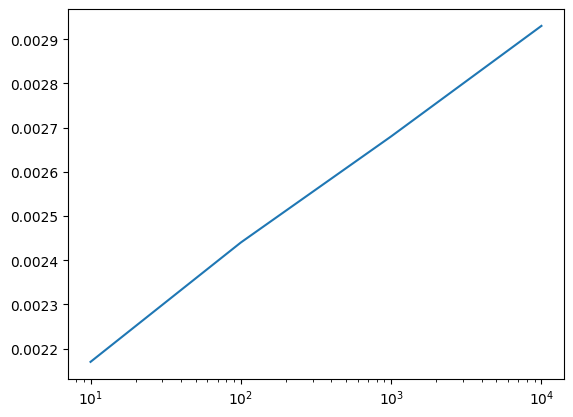

In [171]:
plt.plot(E_GS, a_GS)
plt.xscale('log')
#plt.yscale('log')

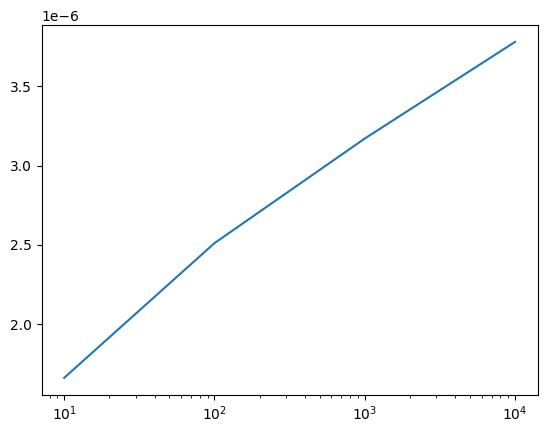

In [170]:
plt.plot(E_GS, b_GS)
plt.xscale('log')
#plt.yscale('log')

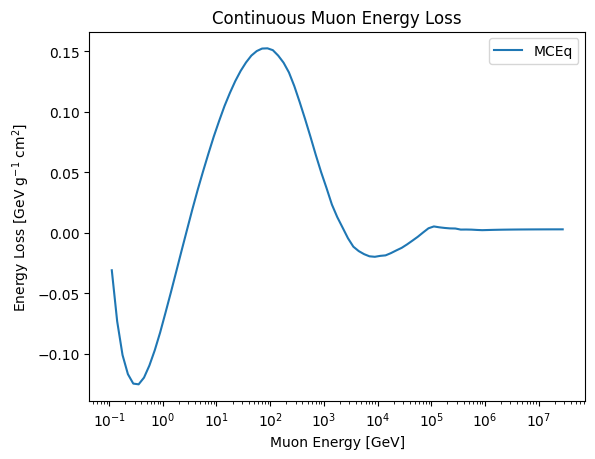

In [75]:
plt.plot(mceq._energy_grid.c, -mceq.pman[-13].dEdX / ((Prop.a + (Prop.b+0.000105)*mceq._energy_grid.c)/100) -1, label='MCEq')
#plt.plot(mceq._energy_grid.c, -mceq.pman[13].dEdX)
#plt.plot(mceq._energy_grid.c, (Prop.a + Prop.b*mceq._energy_grid.c)/100, label='Heisinger approx. (dE/dX = a+bE)')
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Muon Energy [GeV]')
plt.ylabel(r'Energy Loss [GeV g$^{-1}$ cm$^2$]')
plt.legend()
plt.title('Continuous Muon Energy Loss')
plt.show()

In [78]:
Prop.b

0.000244

In [42]:
import MCEq.data

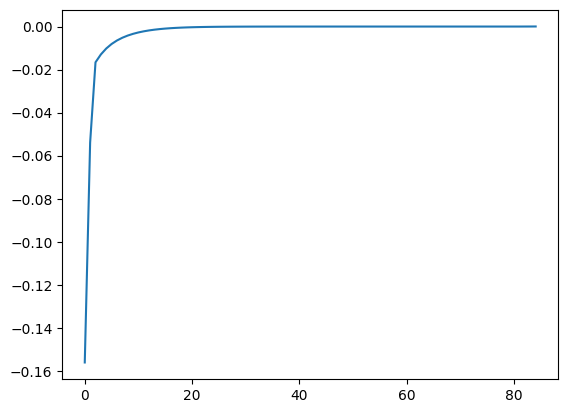

In [142]:
plt.plot(np.diag(np.diag(1/mceq._energy_grid.c) @ mceq.matrix_builder.op_matrix @ np.diag(-mceq.pman[-13].dEdX), 0))

In [90]:
mceq._energy_grid.c

array([1.12201845e-01, 1.41253754e-01, 1.77827941e-01, 2.23872114e-01,
       2.81838293e-01, 3.54813389e-01, 4.46683592e-01, 5.62341325e-01,
       7.07945784e-01, 8.91250938e-01, 1.12201845e+00, 1.41253754e+00,
       1.77827941e+00, 2.23872114e+00, 2.81838293e+00, 3.54813389e+00,
       4.46683592e+00, 5.62341325e+00, 7.07945784e+00, 8.91250938e+00,
       1.12201845e+01, 1.41253754e+01, 1.77827941e+01, 2.23872114e+01,
       2.81838293e+01, 3.54813389e+01, 4.46683592e+01, 5.62341325e+01,
       7.07945784e+01, 8.91250938e+01, 1.12201845e+02, 1.41253754e+02,
       1.77827941e+02, 2.23872114e+02, 2.81838293e+02, 3.54813389e+02,
       4.46683592e+02, 5.62341325e+02, 7.07945784e+02, 8.91250938e+02,
       1.12201845e+03, 1.41253754e+03, 1.77827941e+03, 2.23872114e+03,
       2.81838293e+03, 3.54813389e+03, 4.46683592e+03, 5.62341325e+03,
       7.07945784e+03, 8.91250938e+03, 1.12201845e+04, 1.41253754e+04,
       1.77827941e+04, 2.23872114e+04, 2.81838293e+04, 3.54813389e+04,
      

In [147]:
mceq.matrix_builder.cont_loss_operator(13)[4]

array([ 2.04793860e-06, -3.24634898e-05,  1.68855896e-03, -1.52350373e-02,
       -1.06071542e-02,  3.04576352e-02, -7.32077426e-03,  8.80552266e-04,
        3.49744113e-05, -3.86129316e-06,  1.90463316e-07,  7.44622731e-09,
       -4.91982143e-10,  1.36330725e-11,  4.46188806e-13, -1.97528292e-14,
        3.58772403e-16,  8.64175499e-18, -2.72658353e-19,  3.57131584e-21,
        5.69715409e-23, -1.33225331e-24,  1.33525864e-26,  1.29018301e-28,
       -2.29605120e-30,  1.82707556e-32,  9.78396682e-35, -1.35367498e-36,
        8.76528789e-39,  2.30043965e-41, -2.52877084e-43,  1.36057865e-45,
        1.32824565e-48, -1.19041390e-50,  5.45605896e-53,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  